In [24]:
import pandas as pd

In [6]:
df = pd.read_csv(
    "Abastecimento.csv",
    sep=";",        # separador correto
    decimal=".",    # decimal brasileiro
    encoding="latin1"  # comum em arquivos exportados do Excel
)


In [7]:
df = df[["ANO","DATA", "VEICULO", "TIPO","GASOLINA", "ALCOOL", "DIESEL", "GAS", "KM", "VALOR", "KM RODADA", "MEDIA L/KM", "MOTORISTA", "DESCONTOS"]]

In [8]:
df.head()

,ANO,DATA,VEICULO,TIPO,GASOLINA,ALCOOL,DIESEL,GAS,KM,VALOR,KM RODADA,MEDIA L/KM,MOTORISTA,DESCONTOS
0,2020.0,17/06/2020,PLQ 6I57,SPIN,NaN,NaN,NaN,11.900,107517.0,34.49,NaN,0.0,NaN,NaN
1,2020.0,17/06/2020,PLQ 6I57,SPIN,NaN,45.820,NaN,NaN,107514.0,155.78,NaN,0.0,NaN,NaN
2,2020.0,17/06/2020,PLL 6A56,VAN,NaN,NaN,81.13,NaN,172376.0,239.25,NaN,0.0,NaN,NaN
3,2020.0,17/06/2020,PLQ 7J90,SPIN,NaN,15.157,NaN,NaN,99461.0,50.00,NaN,0.0,NaN,NaN
4,2020.0,28/06/2020,PLQ 7J90,SPIN,NaN,NaN,NaN,12.621,99380.0,35.21,NaN,0.0,NaN,NaN


In [9]:
try:
    from readline import redisplay  # Linux/macOS
except ModuleNotFoundError:
    redisplay = None  # Windows: ignora ou trate de outra forma
import pandas as pd
import numpy as np


df.columns = df.columns.str.strip()
df_model = df[["VEICULO", "KM RODADA", "DIESEL"]].copy()
df_model = df_model.dropna(how="all")

df_model["VEICULO"] = df_model["VEICULO"].astype(str).str.strip()

# KM RODADA: já é numérico → só garante conversão
df_model["KM RODADA"] = pd.to_numeric(df_model["KM RODADA"], errors="coerce")

# DIESEL: vem como string BR → troca vírgula por ponto (NÃO remove ".")
s = df_model["DIESEL"].astype(str).str.strip()
s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan, "NaN": np.nan})
s = s.str.replace(r"\s+", "", regex=True)
s = s.str.replace(",", ".", regex=False)
df_model["DIESEL"] = pd.to_numeric(s, errors="coerce")

# Remover inválidos
df_model = df_model.dropna(subset=["VEICULO", "KM RODADA", "DIESEL"])
df_model = df_model[(df_model["KM RODADA"] > 0) & (df_model["DIESEL"] > 0)]

print("Após limpeza:", df_model.shape)
if redisplay:
    redisplay()
print(df_model.head())

Após limpeza: (5461, 3)
     VEICULO  KM RODADA  DIESEL
12  PLL 6A56      654.0  29.674
19  PLI 3471      571.0  55.630
21  PLJ 2A71      393.0  41.511
25  PLI 3471      365.0  32.241
29  PLJ 2A71      394.0  37.190


In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

In [11]:
X = df_model[["VEICULO", "KM RODADA"]]
y = df_model["DIESEL"]

cat_features = ["VEICULO"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="MAE",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

In [14]:
preds = model.predict(X_test)

print("MAE (erro médio em litros):", mean_absolute_error(y_test, preds))
print("R²:", r2_score(y_test, preds))

MAE (erro médio em litros): 4.035694177515348
R²: 0.8946966389349341


In [15]:
def recomendar_veiculos(km_rota, top_n=5):
    veiculos = df_model[["VEICULO"]].drop_duplicates().reset_index(drop=True)

    veiculos["KM RODADA"] = km_rota
    veiculos["LITROS_PREVISTOS"] = model.predict(veiculos)

    ranking = veiculos.sort_values("LITROS_PREVISTOS").head(top_n)
    return ranking

In [16]:
recomendar_veiculos(km_rota=164)

,VEICULO,KM RODADA,LITROS_PREVISTOS
20,TRANSIT,164,15.981656
17,PLI 1025,164,16.420908
16,PLD 4933,164,16.420908
22,PLQ 7J90,164,16.420908
1,PLI 3471,164,16.684348


In [19]:
recomendar_veiculos(km_rota=417)

,VEICULO,KM RODADA,LITROS_PREVISTOS
3,PLQ 6I57,417,37.413501
7,PLR 4F49,417,37.413501
8,PLR 8E03,417,39.763718
2,PLJ 2A71,417,39.855066
1,PLI 3471,417,39.940792


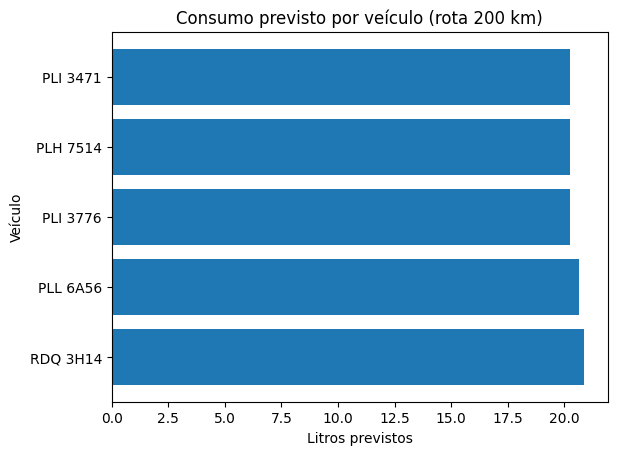

In [20]:
import matplotlib.pyplot as plt

resultado = recomendar_veiculos(km_rota=200)

plt.figure()
plt.barh(resultado["VEICULO"], resultado["LITROS_PREVISTOS"])
plt.xlabel("Litros previstos")
plt.ylabel("Veículo")
plt.title("Consumo previsto por veículo (rota 200 km)")
plt.gca().invert_yaxis()
plt.show()